In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#import functions
from data_preprocessing import prepare_X, get_labels, clean_text, lemmatize

## Load Data

In [26]:
data_train = pd.read_csv('dataset/data.csv', encoding="utf8")
data_inference = pd.read_csv('dataset/validation_data.csv', encoding="utf8")

## Prepare Data

In [27]:
X_prepared = prepare_X(data_train)
labels_train = get_labels(data_train, X_prepared.index)
X_prepared = X_prepared.reset_index(drop=True) 


## Train-Test-Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared['text'], labels_train, test_size=0.2, random_state=42
)

## Data-cleaning and Lemmatization

In [29]:
#load cleaned and lemmatized data

X_train_clean = pd.read_csv('dataset/X_train_cleaned.csv').squeeze("columns").fillna("")
X_test_clean = pd.read_csv('dataset/X_test_cleaned.csv').squeeze("columns").fillna("")


## TFIDF-Vectorizer

In [30]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)


## Train models and make predictions

In [31]:
tfidf_model = MultinomialNB()
tfidf_model.fit(X_train_vec, y_train)

#predictions
predictions = tfidf_model.predict(X_test_vec)
print(f"Naive Bayes Accuracy (TFIDF-Vectorizer): {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Naive Bayes Accuracy (TFIDF-Vectorizer): 0.9399

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93      3297
           1       0.93      0.97      0.95      3989

    accuracy                           0.94      7286
   macro avg       0.94      0.94      0.94      7286
weighted avg       0.94      0.94      0.94      7286



## Confusion matrix

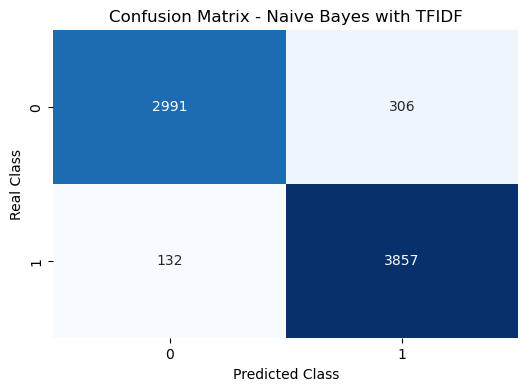

In [32]:
conf_matrix = confusion_matrix(y_test, predictions)

# 2. Plot erstellen
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=tfidf_model.classes_, 
            yticklabels=tfidf_model.classes_)

plt.xlabel('Predicted Class')
plt.ylabel('Real Class')
plt.title('Confusion Matrix - Naive Bayes with TFIDF')
plt.show()

## Look at examples from Inference Set

In [33]:
# load dataset
inference_data = pd.read_csv('dataset/validation_data.csv', encoding="utf8")

mini_inference_set = inference_data.sample(n=20, random_state=42)

In [34]:
# prepare the subset
mini_prepared = prepare_X(mini_inference_set)

mini_clean = mini_prepared['text'].apply(clean_text).apply(lemmatize)


In [35]:
#vectorize mini set
X_mini_vec = vectorizer.transform(mini_clean)

In [36]:
# make predictions on mini set

In [37]:
mini_preds = tfidf_model.predict(X_mini_vec)

## Examples

In [24]:
# show predictions
for i, (idx, row) in enumerate(mini_inference_set.iterrows()):
    pred_label = mini_preds[i]
    print(f"\n[News {i+1}] - Model prediction: {pred_label}")
    print(f"Article: {row['text'][:200]}...")
    print("-" * 50)


[News 1] - Model prediction: 0
Article: This is so over the top it s not funny. I m a huge advocate of parents being there for the kids but a felony charge? Held overnight in jail? Does anyone out there have anything new to add to this or i...
--------------------------------------------------

[News 2] - Model prediction: 0
Article: I m pretty sure Trump will win with a YUGE majority in New York without his kids votes. Eric Trump and Ivanka Trump won t be voting for their father, Donald, in the New York primary next week.The dead...
--------------------------------------------------

[News 3] - Model prediction: 0
Article: Pray for these police officers, the innocent citizens, residents and business owners in Baltimore Here is a recruitment flyer that was posted by the Black Panthers leading up to the start of the riots...
--------------------------------------------------

[News 4] - Model prediction: 0
Article: Trump spoke to his supporters at a rally in Cleveland, Ohio, on Saturda